<a href="https://colab.research.google.com/github/GabrielaRguezCampos/MiamiHeatRecommendationCupon/blob/main/Game_Recommendation_System_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommendation System Demo

## Imports and connect to data

In [ ]:
# STEP 1: Install and import what we need
!pip install gspread google-auth

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import auth
from google.auth import default
import gspread

In [ ]:
# STEP 2: Connect to your real survey data
def get_real_survey_data():
    """
    Get data from your Shopping_Behavior_Data sheet
    """
    print("🔐 Connecting to Google...")

    # Authenticate
    auth.authenticate_user()
    creds, _ = default()
    gc = gspread.authorize(creds)

    # Get your survey data
    print("📊 Getting your survey data...")
    sheet = gc.open("Shopping_Behavior_Data").sheet1
    data = sheet.get_all_records()
    df = pd.DataFrame(data)

    print(f"✅ Got {len(df)} survey responses!")
    return df

## Analyze the data

In [ ]:
# STEP 3: Analyze the data
def analyze_survey_data(df):
    """
    Simple analysis of your survey data
    """
    print("\n📋 YOUR SURVEY DATA OVERVIEW:")
    print("=" * 40)
    print(f"Total responses: {len(df)}")

    # Show column names
    print("\nColumns in your data:")
    for i, col in enumerate(df.columns, 1):
        print(f"  {i}. {col}")

    # Show first few responses
    print("\nFirst 3 responses:")
    print(df.head(3))

    return df

## Finding patterns

In [ ]:
# STEP 4: Find breakfast patterns
def find_breakfast_patterns(df):
    """
    Find what breakfast items people buy together
    """
    print("\n🥞 BREAKFAST BUYING PATTERNS:")
    print("=" * 40)

    # Find the breakfast column
    breakfast_col = None
    for col in df.columns:
        if 'breakfast' in col.lower():
            breakfast_col = col
            break

    if not breakfast_col:
        print("❌ No breakfast column found")
        return

    print(f"Using column: {breakfast_col}")

    # Count breakfast items
    all_items = []
    for response in df[breakfast_col]:
        if pd.notna(response) and str(response).strip():
            # Handle semicolon or comma separated items
            if ';' in str(response):
                items = [item.strip() for item in str(response).split(';')]
            elif ',' in str(response):
                items = [item.strip() for item in str(response).split(',')]
            else:
                items = [str(response).strip()]

            all_items.extend(items)

    # Show most popular items
    item_counts = Counter(all_items)
    print("\nMost popular breakfast items:")
    for item, count in item_counts.most_common(8):
        percentage = (count / len(df)) * 100
        print(f"  • {item}: {count} people ({percentage:.0f}%)")

    # Simple chart
    plt.figure(figsize=(10, 5))
    items = [item for item, count in item_counts.most_common(6)]
    counts = [count for item, count in item_counts.most_common(6)]
    plt.bar(items, counts)
    plt.title('Most Popular Breakfast Items')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return item_counts

## Generate recommendations

In [ ]:
# STEP 5: Generate recommendations for real people
def recommend_for_real_people(df):
    """
    Generate recommendations for your actual survey participants
    """
    print("\n🎯 RECOMMENDATIONS FOR YOUR REAL PARTICIPANTS:")
    print("=" * 50)

    # Find important columns
    name_col = None
    breakfast_col = None
    dinner_col = None

    for col in df.columns:
        if 'name' in col.lower():
            name_col = col
        elif 'breakfast' in col.lower():
            breakfast_col = col
        elif 'dinner' in col.lower():
            dinner_col = col

    # Get people who shared names
    if name_col:
        named_people = df[df[name_col].notna() & (df[name_col] != '')].copy()
        print(f"Found {len(named_people)} people who shared names:")

        for _, person in named_people.head(4).iterrows():
            name = person[name_col]
            print(f"\n👤 {name.upper()}'S RECOMMENDATIONS:")
            print("-" * 30)

            # What they chose
            if breakfast_col and pd.notna(person[breakfast_col]):
                breakfast = str(person[breakfast_col])
                print(f"You chose for breakfast: {breakfast}")

                # Simple recommendations
                if 'Bread' in breakfast and 'Butter' not in breakfast:
                    print("💡 Recommendation: Try BUTTER with your bread!")
                if 'Coffee' in breakfast and 'Milk' not in breakfast:
                    print("💡 Recommendation: Add MILK for your coffee!")
                if 'Milk' in breakfast and 'Cereal' not in breakfast:
                    print("💡 Recommendation: CEREAL goes great with milk!")

            if dinner_col and pd.notna(person[dinner_col]):
                dinner = str(person[dinner_col])
                print(f"You chose for dinner: {dinner}")

                if 'Pizza' in dinner:
                    print("💡 Recommendation: SOFT DRINKS pair perfectly with pizza!")
                if 'Pasta' in dinner:
                    print("💡 Recommendation: Try PARMESAN CHEESE with pasta!")
                if 'Salad' in dinner:
                    print("💡 Recommendation: OLIVE OIL makes salads better!")

    else:
        print("No names found - showing general recommendations")


## Interactive presentation script

In [ ]:
# STEP 6: Interactive presentation script
def create_presentation_script(df):
    """
    Create your live presentation script
    """
    print("\n🎭 YOUR LIVE PRESENTATION SCRIPT:")
    print("=" * 50)

    # Find name column
    name_col = None
    dinner_col = None
    for col in df.columns:
        if 'name' in col.lower():
            name_col = col
        elif 'dinner' in col.lower():
            dinner_col = col

    if name_col and dinner_col:
        named_people = df[df[name_col].notna() & (df[name_col] != '')].copy()

        for _, person in named_people.head(2).iterrows():
            name = person[name_col]
            dinner = person[dinner_col] if pd.notna(person[dinner_col]) else "Not specified"

            print(f"\n🎤 FOR {name.upper()}:")
            print(f"SAY: '{name}, you chose {dinner} for dinner.'")
            print(f"ASK: 'What would you drink with that?'")
            print(f"[Wait for their answer...]")

            if 'Pizza' in str(dinner):
                print(f"REVEAL: 'Our algorithm predicts SOFT DRINKS!'")
            elif 'Pasta' in str(dinner):
                print(f"REVEAL: 'Our algorithm predicts SOFT DRINKS!'")
            elif 'Salad' in str(dinner):
                print(f"REVEAL: 'Our algorithm predicts WATER!'")
            else:
                print(f"REVEAL: 'Our algorithm predicts based on similar choices!'")

            print(f"ASK: 'Did we get it right, {name}?'")

## Run everything

🚀 RECOMMENDATION SYSTEM DEMO WITH YOUR REAL DATA
🔐 Connecting to Google...
📊 Getting your survey data...
✅ Got 10 survey responses!

📋 YOUR SURVEY DATA OVERVIEW:
Total responses: 10

Columns in your data:
  1. Timestamp
  2.   Your name or nickname for personalized demo  recommendations 
  3. What's your primary goal when grocery shopping? 
  4. You enter the store. Where do you typically go first? 
  5. Which breakfast items do you typically buy together? (Select all that apply) 
  6. You're planning dinner. What sounds appealing? 
  7. What beverages are you most likely to purchase? 
  8. Your age group: 
  9.   When you buy snacks, what do you typically choose?  
  10. Shopping Frequency 
  11. At checkout, you're most likely to grab: 

First 3 responses:
           Timestamp  \
0  7/1/2025 17:32:28   
1  7/1/2025 17:43:36   
2  7/1/2025 17:44:44   

    Your name or nickname for personalized demo  recommendations   \
0                                           Kingsley             

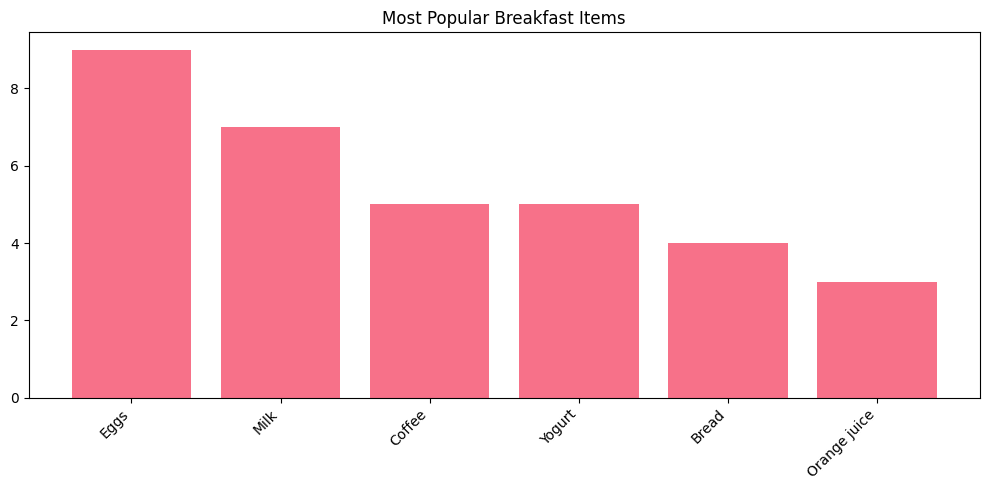


🎯 RECOMMENDATIONS FOR YOUR REAL PARTICIPANTS:
Found 10 people who shared names:

👤 KINGSLEY'S RECOMMENDATIONS:
------------------------------
You chose for breakfast: Milk
💡 Recommendation: CEREAL goes great with milk!
You chose for dinner: Homemade pizza

👤 ME'S RECOMMENDATIONS:
------------------------------
You chose for breakfast: Milk, Eggs
💡 Recommendation: CEREAL goes great with milk!
You chose for dinner: Pasta with sauce
💡 Recommendation: Try PARMESAN CHEESE with pasta!

👤 GABY'S RECOMMENDATIONS:
------------------------------
You chose for breakfast: Butter, Coffee, Eggs, Orange juice
💡 Recommendation: Add MILK for your coffee!
You chose for dinner: Homemade pizza

👤 ANETTE'S RECOMMENDATIONS:
------------------------------
You chose for breakfast: Milk, Eggs, Yogurt
💡 Recommendation: CEREAL goes great with milk!
You chose for dinner: Grilled meat/fish

🎭 YOUR LIVE PRESENTATION SCRIPT:

🎤 FOR KINGSLEY:
SAY: 'Kingsley, you chose Homemade pizza for dinner.'
ASK: 'What would you

In [ ]:
# STEP 7: Run everything
def run_demo():
    """
    Run the complete demo with your real data
    """
    print("🚀 RECOMMENDATION SYSTEM DEMO WITH YOUR REAL DATA")
    print("=" * 60)

    # Get your real survey data
    df = get_real_survey_data()

    # Analyze it
    df = analyze_survey_data(df)

    # Find patterns
    breakfast_patterns = find_breakfast_patterns(df)

    # Generate recommendations
    recommend_for_real_people(df)

    # Create presentation script
    create_presentation_script(df)

    print("\n🎊 DEMO COMPLETE!")
    print("You now have real recommendations for your real participants!")

    return df

# RUN THE DEMO
survey_data = run_demo()